# 01 - Preparación del Dataset en PyTorch

## 1. Imports y configuración

In [ ]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import torch
from torch.utils.data import DataLoader

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from prod.detection_dataset import (
    CarDamageDetectionDataset,
    ComposeDetection,
    RandomHorizontalFlipDetection,
    ToTensorDetection,
    collate_fn,
)


In [9]:
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    DATA_DIR = Path("/content/data")
else:
    DATA_DIR = Path("../data")

print("Entorno Colab:", IS_COLAB)
print("DATA_DIR:", DATA_DIR)


Entorno Colab: False
DATA_DIR: ../data


## 1.b Instalación opcional de dependencias

Instala dependencias si el notebook corre en Google Colab.

In [10]:
if IS_COLAB:
    import subprocess

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "matplotlib",
        "pillow",
        "torch",
        "torchvision",
    ])
else:
    print("Instalación opcional omitida: usá tu entorno local con requirements.txt")


Instalación opcional omitida: usá tu entorno local con requirements.txt


## 8. Creación de las transoformaciones a aplicar para entrenamiento y para evaluación

Convierte imágenes a tensor y aplica augmentations que preservan las boxes.

In [11]:
train_transform = ComposeDetection([
    ToTensorDetection(),
    RandomHorizontalFlipDetection(p=0.5),
])

eval_transform = ComposeDetection([
    ToTensorDetection(),
])


## 9. DataLoaders

Crea los DataLoaders

In [ ]:
MODEL_NAME = "fasterrcnn"
USE_FIXED_IMAGE_SIZE = False
IMAGE_SIZE = None
BATCH_SIZE = 2

train_dataset = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="train",
    transform=train_transform,
    model_name=MODEL_NAME,
    resize=USE_FIXED_IMAGE_SIZE,
    image_size=IMAGE_SIZE,
)

val_dataset = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="val",
    transform=eval_transform,
    model_name=MODEL_NAME,
    resize=USE_FIXED_IMAGE_SIZE,
    image_size=IMAGE_SIZE,
)

test_dataset = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="test",
    transform=eval_transform,
    model_name=MODEL_NAME,
    resize=USE_FIXED_IMAGE_SIZE,
    image_size=IMAGE_SIZE,
)

class_to_idx = train_dataset.class_to_idx
idx_to_class = train_dataset.idx_to_class

num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)


## 10. Visualización de augmentations

Muestra imágenes de entrenamiento con bounding boxes antes y después de las transformaciones.

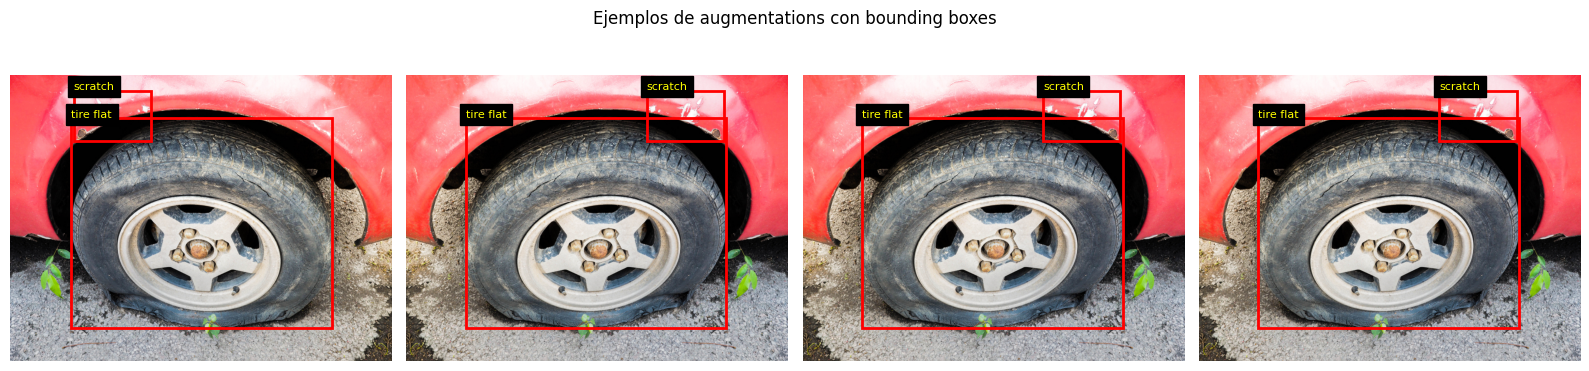

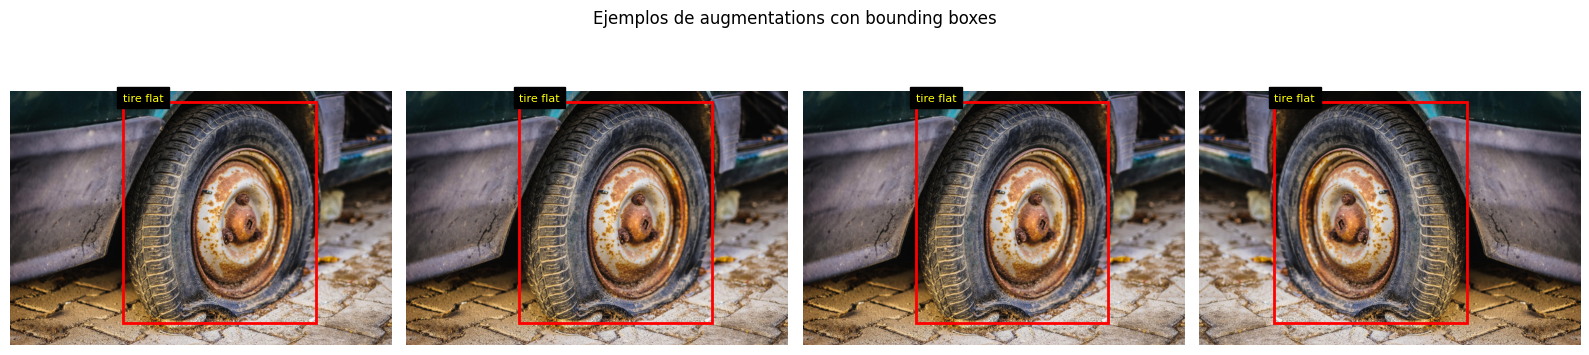

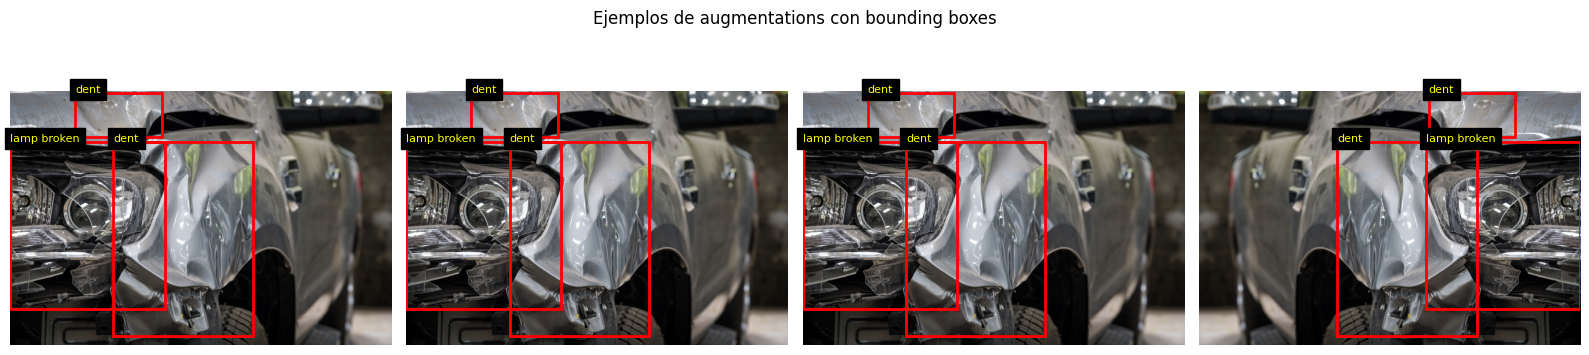

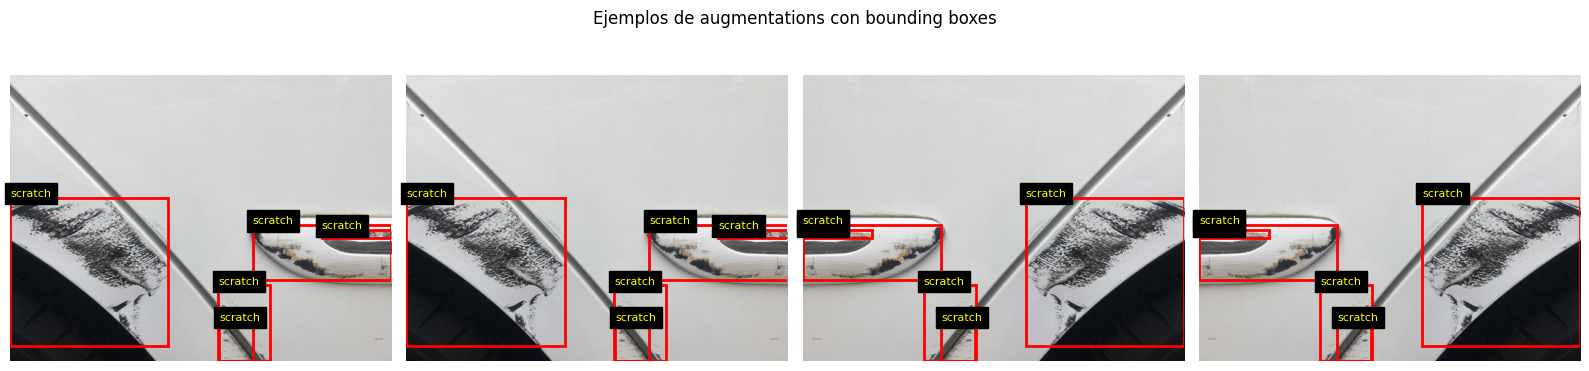

In [13]:
def draw_boxes(ax, image_tensor, target, idx_to_class, title=None):
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    ax.imshow(image)
    ax.axis("off")

    for box, label in zip(target["boxes"], target["labels"]):
        xmin, ymin, xmax, ymax = box.tolist()
        width = xmax - xmin
        height = ymax - ymin
        rect = Rectangle((xmin, ymin), width, height, fill=False, edgecolor="red", linewidth=2)
        ax.add_patch(rect)
        ax.text(xmin, max(ymin - 2, 0), idx_to_class[int(label.item())], color="yellow", fontsize=8, backgroundcolor="black")

    if title:
        ax.set_title(title)


def show_augmentations(dataset, index, n=4):
    if len(dataset) == 0:
        print("El dataset está vacío.")
        return

    index = min(index, len(dataset) - 1)
    image, base_target = dataset.get_raw_sample(index)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for axis in axes:
        transformed_image, transformed_target = train_transform(
            image.copy(),
            {
                "boxes": base_target["boxes"].clone(),
                "labels": base_target["labels"].clone(),
                "image_id": base_target["image_id"].clone(),
                "area": base_target["area"].clone(),
                "iscrowd": base_target["iscrowd"].clone(),
            },
        )
        draw_boxes(axis, transformed_image, transformed_target, idx_to_class)

    plt.suptitle("Ejemplos de augmentations con bounding boxes")
    plt.tight_layout()
    plt.show()

candidate_indices = [0, 10, 20, 30]
valid_indices = [idx for idx in candidate_indices if idx < len(train_dataset)]

for idx in valid_indices:
    show_augmentations(train_dataset, index=idx, n=4)

if not valid_indices:
    print("No hay suficientes imágenes para mostrar augmentations.")


## 11. Verificación final de batches

Verifica batch sizes, shapes y visualización final con bounding boxes.

In [14]:
images, targets = next(iter(train_loader))

print("Cantidad de imágenes en el batch:", len(images))
print("Cantidad de targets en el batch:", len(targets))
print("Shape de la primera imagen:", images[0].shape)
print("Shape de boxes de la primera muestra:", targets[0]["boxes"].shape)
print("Valor mínimo de la primera imagen:", images[0].min().item())
print("Valor máximo de la primera imagen:", images[0].max().item())


RuntimeError: stack expects each tensor to be equal size, but got [1, 4] at entry 0 and [3, 4] at entry 1